# Task 2: Financial News Sentiment Classification

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/zhengmingqin/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/zhengmingqin/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/zhengmingqin/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/zhengmingqin/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## 2.1 Method Implementation and Rationale

### Data Exploration

In [46]:
# Load the dataset
df = pd.read_csv('data.csv', encoding='latin-1')
print('Dataset shape:', df.shape)
print('\nFirst few rows:')
df.head()

Dataset shape: (5842, 2)

First few rows:


,Sentence,Sentiment
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,According to the Finnish-Russian Chamber of Co...,neutral
4,The Swedish buyout firm has sold its remaining...,neutral


Sentiment class distribution:
Sentiment
neutral     3130
positive    1852
negative     860
Name: count, dtype: int64

Class proportions:
Sentiment
neutral     0.536
positive    0.317
negative    0.147
Name: proportion, dtype: float64


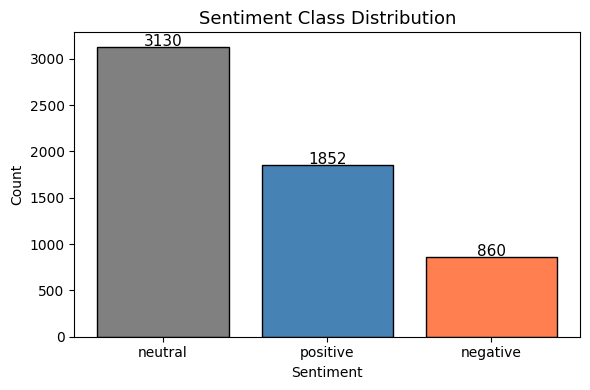

In [47]:
# Check class distribution
print('Sentiment class distribution:')
print(df['Sentiment'].value_counts())
print(f'\nClass proportions:')
print(df['Sentiment'].value_counts(normalize=True).round(3))

# Plot class distribution
plt.figure(figsize=(6, 4))
counts = df['Sentiment'].value_counts()
colors = {'positive': 'steelblue', 'negative': 'coral', 'neutral': 'grey'}
bars = plt.bar(counts.index, counts.values,
               color=[colors.get(c, 'grey') for c in counts.index],
               edgecolor='black')
for bar, v in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, v + 10, str(v), ha='center', fontsize=11)
plt.title('Sentiment Class Distribution', fontsize=13)
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=100)
plt.show()

### Preprocessing

In [48]:
import re

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# We keep some financial negation words that could be informative
stop_words -= {'no', 'not', 'nor', 'against', 'up', 'down'}

def preprocess_text(text):
    # lowercase
    text = str(text).lower()
    # remove numbers and punctuation, keep only letters
    text = re.sub(r'[^a-z\s]', ' ', text)
    # tokenize
    tokens = word_tokenize(text)
    # remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 1]
    return ' '.join(tokens)

# Apply preprocessing to all texts
df['clean_text'] = df['Sentence'].apply(preprocess_text)

print('Example:')
print('Original: ', df['Sentence'].iloc[0])
print('Cleaned:  ', df['clean_text'].iloc[0])

Example:
Original:  The GeoSolutions technology will leverage Benefon 's GPS solutions by providing Location Based Search Technology , a Communities Platform , location relevant multimedia content and a new and powerful commercial model .
Cleaned:   geosolutions technology leverage benefon gps solution providing location based search technology community platform location relevant multimedia content new powerful commercial model


### TF-IDF Features + Logistic Regression

In [49]:
# Encode labels as integers
label_map = {'positive': 2, 'neutral': 1, 'negative': 0}
label_names = ['negative', 'neutral', 'positive']
df['label'] = df['Sentiment'].map(label_map)

texts = df['clean_text'].values
labels = df['label'].values

# 80/20 train/test split, stratified to keep class balance
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f'Train size: {len(X_train_raw)}, Test size: {len(X_test_raw)}')
print(f'Train class counts: {Counter(y_train)}')
print(f'Test class counts: {Counter(y_test)}')

Train size: 4673, Test size: 1169
Train class counts: Counter({1: 2504, 2: 1481, 0: 688})
Test class counts: Counter({1: 626, 2: 371, 0: 172})


In [50]:
# Build TF-IDF feature vectors
# max_features limits the vocabulary to the most important words
# ngram_range=(1,2) includes both single words and word pairs
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2
)

# Fit on training data only (avoid data leakage)
X_train = vectorizer.fit_transform(X_train_raw)
X_test = vectorizer.transform(X_test_raw)

print(f'TF-IDF feature matrix shape: {X_train.shape}')
print(f'Vocabulary size: {len(vectorizer.vocabulary_)}')

TF-IDF feature matrix shape: (4673, 9553)
Vocabulary size: 9553


In [51]:
# Train Logistic Regression
# C controls regularisation strength
lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42, multi_class='multinomial')
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)

print('=== Logistic Regression with TF-IDF ===')
print(f'Accuracy:       {accuracy_score(y_test, y_pred):.4f}')
print(f'F1 (macro):     {f1_score(y_test, y_pred, average="macro"):.4f}')
print(f'F1 (weighted):  {f1_score(y_test, y_pred, average="weighted"):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=label_names))

=== Logistic Regression with TF-IDF ===
Accuracy:       0.7126
F1 (macro):     0.5786
F1 (weighted):  0.6865

Classification Report:
              precision    recall  f1-score   support

    negative       0.37      0.15      0.21       172
     neutral       0.71      0.88      0.79       626
    positive       0.79      0.68      0.73       371

    accuracy                           0.71      1169
   macro avg       0.62      0.57      0.58      1169
weighted avg       0.69      0.71      0.69      1169



## 2.2 Evaluation, Interpretation and Discussion

<Figure size 700x500 with 0 Axes>

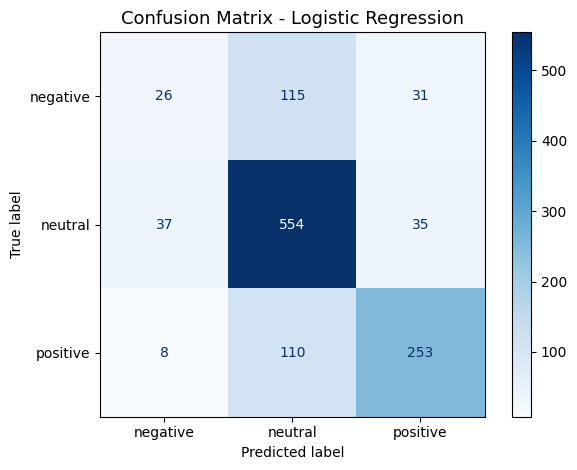


Normalised confusion matrix (row = true class):
          negative  neutral  positive
negative     0.151    0.669     0.180
neutral      0.059    0.885     0.056
positive     0.022    0.296     0.682


In [52]:
# Confusion matrix
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=label_names)
disp.plot(colorbar=True, cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix_t2.png', dpi=100)
plt.show()

# Also print normalised version
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
print('\nNormalised confusion matrix (row = true class):')
print(pd.DataFrame(cm_norm, index=label_names, columns=label_names).round(3))

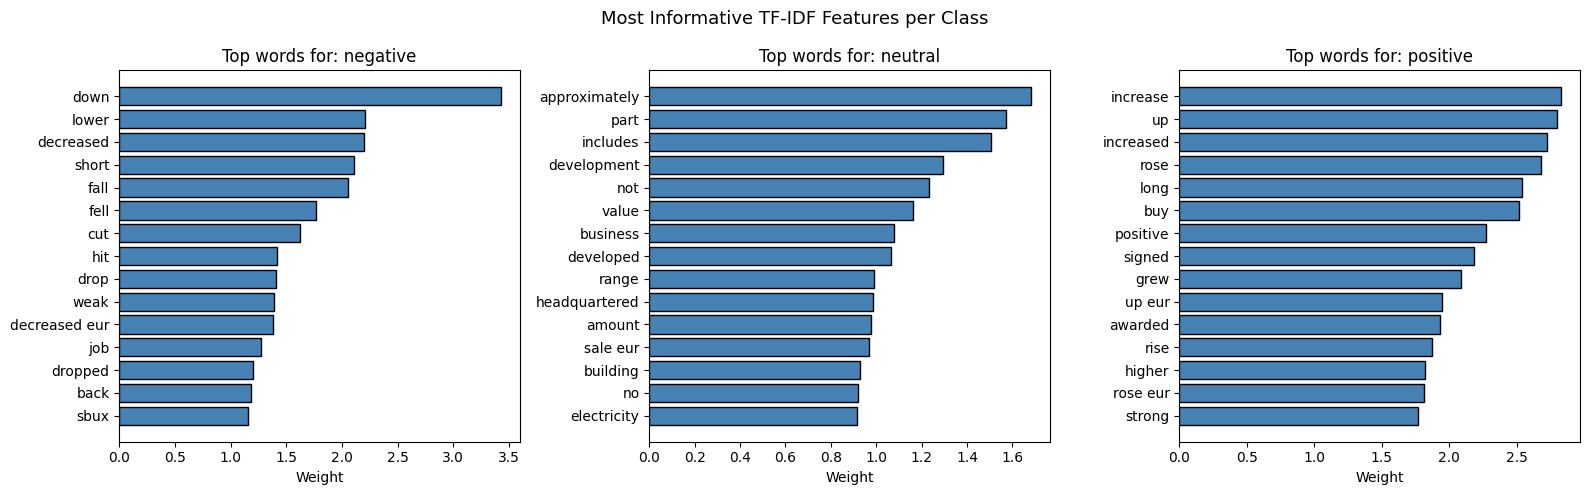

In [53]:
# Look at the most informative features for each class
vocab = vectorizer.get_feature_names_out()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, (class_name, coefs) in enumerate(zip(label_names, lr.coef_)):
    top_idx = np.argsort(coefs)[-15:]  # top 15 features
    top_words = [vocab[j] for j in top_idx]
    top_coefs = coefs[top_idx]
    axes[i].barh(top_words, top_coefs, color='steelblue', edgecolor='black')
    axes[i].set_title(f'Top words for: {class_name}', fontsize=12)
    axes[i].set_xlabel('Weight')
plt.suptitle('Most Informative TF-IDF Features per Class', fontsize=13)
plt.tight_layout()
plt.savefig('top_features_t2.png', dpi=100)
plt.show()

In [55]:
# Error analysis - look at misclassified examples
errors = np.where(y_pred != y_test)[0]
print(f'Total misclassified: {len(errors)} / {len(y_test)} ({len(errors)/len(y_test)*100:.1f}%)')

# Show examples of each error type
print('\n--- Examples of misclassified sentences ---')
shown = 0
for idx in errors:
    if shown >= 12:
        break
    true_label = label_names[y_test[idx]]
    pred_label = label_names[y_pred[idx]]
    text = X_test_raw[idx]
    print(f'True: {true_label:8s} | Pred: {pred_label:8s} | "{text[:100]}"')
    shown += 1

Total misclassified: 336 / 1169 (28.7%)

--- Examples of misclassified sentences ---
True: positive | Pred: neutral  | "nordic business report june metso corporation win eur equipment order australia communication ltd fi"
True: negative | Pred: neutral  | "profit tax amounted eur mn down eur mn"
True: neutral  | Pred: positive | "rad chart flashing oversold"
True: negative | Pred: positive | "nflx say time short point"
True: negative | Pred: neutral  | "finnish kemira net sale eur decreased eur mn january june eur mn january june"
True: negative | Pred: neutral  | "liquidity providing interrupted may aspocomp group oyj share traded cent aspocomp stock exchange rel"
True: negative | Pred: positive | "tesco set sell kipa giraffe business sky news"
True: negative | Pred: neutral  | "gps gap september comparable store sale"
True: neutral  | Pred: positive | "intertek group announces strategic update outlining plan"
True: positive | Pred: neutral  | "ceo bpm ubi meet italy econ minister tal

In [42]:
# Which confusion pairs are most common?
error_pairs = Counter(zip(y_test[errors], y_pred[errors]))
print('Most common error types (true label -> predicted label):')
for (true, pred), count in error_pairs.most_common():
    print(f'  {label_names[true]:8s} -> {label_names[pred]:8s}: {count} errors')

Most common error types (true label -> predicted label):
  negative -> neutral : 115 errors
  positive -> neutral : 110 errors
  neutral  -> negative: 37 errors
  neutral  -> positive: 35 errors
  negative -> positive: 31 errors
  positive -> negative: 8 errors


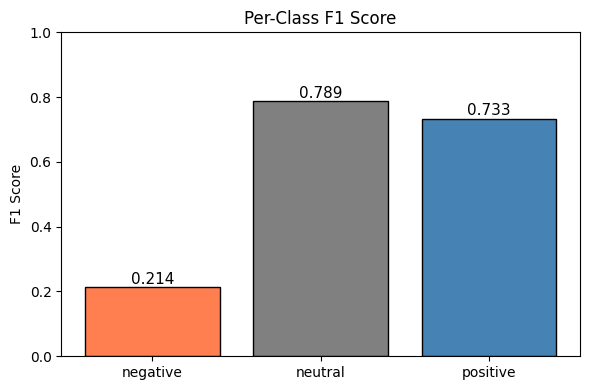

In [43]:
# Per-class F1 score bar chart
from sklearn.metrics import f1_score as f1s
f1_per_class = f1s(y_test, y_pred, average=None)

plt.figure(figsize=(6, 4))
plt.bar(label_names, f1_per_class, color=['coral', 'grey', 'steelblue'], edgecolor='black')
plt.ylim(0, 1)
plt.ylabel('F1 Score')
plt.title('Per-Class F1 Score')
for i, v in enumerate(f1_per_class):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('per_class_f1.png', dpi=100)
plt.show()